In [56]:
import subprocess
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd()
while not (ROOT / "CMakeLists.txt").exists():
    ROOT = ROOT.parent
BIN = ROOT / "build" / "boris_pusher"
DATA = ROOT / "data" / "boris"
FIG = DATA / "figures"
FIG.mkdir(parents=True, exist_ok=True)
subprocess.run(["cmake", "--build", str(ROOT / "build")], check=True, capture_output=True)


CompletedProcess(args=['cmake', '--build', '/Users/paulvuattier/Desktop/M2/HPC/weeks_NA/boris_pusher/build'], returncode=0, stdout=b'[ 33%] Built target boris_pusher\n[ 66%] Built target pic_pusher\n[100%] Built target pic_unit\n', stderr=b'')

# Boris pusher test

| # | Test | |
|---|---|---|
| 1 | Gyration | the magnetic rotation |
| 2 | Energy conservation | no numerical heating in a magnetic field |
| 3 | E×B drift | the electric kicks and the rotation work together |
| 4 | N particles | pushing an array = pushing particles one by one |
| 5 | Mixed species | each particle in the array uses its own charge and mass |

Protons in SI units, $B = 1$ T, $\Delta t = 10^{-10}$ s (about 650 steps per gyration).

In [57]:
Q, M = 1.602176634e-19, 1.67262192369e-27        # proton charge (C), mass (kg)
B0, dt = 1.0, 1e-10
wc = Q * B0 / M                                  # cyclotron frequency
Tc = 2 * np.pi / wc                              # cyclotron period

def run(name, particles, E=(0, 0, 0), B=(0, 0, 1), steps=1000, stride=1):
    # Push particles (rows q, m, x, y, z, vx, vy, vz) with boris_pusher; return the trajectory table.
    ic, out = DATA / f"{name}_ic.csv", DATA / f"{name}.csv"
    np.savetxt(ic, np.atleast_2d(particles), delimiter=",", header="q,m,x,y,z,vx,vy,vz", comments="")
    vec = lambda v: ",".join(map(str, v))
    subprocess.run([BIN, "--run-array", out, ic, f"E={vec(E)}", f"B={vec(B)}",
                    f"dt={dt}", f"steps={steps}", f"stride={stride}"], check=True, capture_output=True)
    return np.genfromtxt(out, delimiter=",", names=True)

def compare_value(label, code, theory, unit=""):
    # one line: value computed by the code next to the theoretical value
    print(f"{label:<48s} code = {code: .6e} {unit:<5s}  theory = {theory: .6e} {unit}")

## Data files 
Each run of `boris_pusher --run-array` uses two CSV files in `data/boris/`. The cell below pushes two example particles for 5 steps and shows both with pandas:

| File | Written by | One row = |
|---|---|---|
| `*_ic.csv` | the notebook (input) | one particle at $t = 0$ |
| `*.csv` | `boris_pusher` | one particle at one output time |

Units are SI. Positions are at whole time steps; velocities are half a step behind them (leapfrog).

## show tables

In [58]:
import pandas as pd
pd.set_option("display.max_columns", 20)
pd.set_option("display.max_colwidth", None)

def show(path, meaning, rows=3):
    # Load a CSV with pandas, list its columns with their meaning, and show the first rows.
    df = pd.read_csv(path)
    print(f"{Path(path).name}: {len(df)} rows x {len(df.columns)} columns")
    display(pd.DataFrame({"meaning": [meaning.get(c, "") for c in df.columns]}, index=df.columns))
    display(df.head(rows))
    return df


two = [[Q, M, 0, 0, 0, 1e5, 0, 0],               # a proton
       [2 * Q, 4 * M, 1e-3, 0, 0, 0, 1e5, 0]]    # an alpha particle
run("example", two, steps=5)

vel = {f"v{c}": f"velocity {c} (m/s)" for c in "xyz"}
pos = {c: f"position {c} (m)" for c in "xyz"}
show(DATA / "example_ic.csv", {"q": "charge (C)", "m": "mass (kg)", **pos, **vel})
show(DATA / "example.csv", {"pid": "particle index (row of the IC file)", "t": "time (s)", **pos,
                            **{k: v + ", half a step behind x" for k, v in vel.items()}});


example_ic.csv: 2 rows x 8 columns


,meaning
q,charge (C)
m,mass (kg)
x,position x (m)
y,position y (m)
z,position z (m)
vx,velocity x (m/s)
vy,velocity y (m/s)
vz,velocity z (m/s)


,q,m,x,y,z,vx,vy,vz
0,1.602177e-19,1.672622e-27,0.000,0.0,0.0,100000.0,0.0,0.0
1,3.204353e-19,6.690488e-27,0.001,0.0,0.0,0.0,100000.0,0.0


example.csv: 12 rows x 8 columns


,meaning
pid,particle index (row of the IC file)
t,time (s)
x,position x (m)
y,position y (m)
z,position z (m)
vx,"velocity x (m/s), half a step behind x"
vy,"velocity y (m/s), half a step behind x"
vz,"velocity z (m/s), half a step behind x"


,pid,t,x,y,z,vx,vy,vz
0,0,0.000000e+00,0.00000,0.000000e+00,0.0,100000.000000,0.000000,0.0
1,1,0.000000e+00,0.00100,0.000000e+00,0.0,0.000000,100000.000000,0.0
2,0,1.000000e-10,0.00001,-9.578613e-08,0.0,99995.412403,-957.861344,0.0


## test 1 - Gyration

why --> test action of B

how --> circle of gyration must be $r_L = m v_0/(qB)$ at angular frequency $\omega_c = qB/m$.  with $m$, $v$, $q$ mass, velocity  and charge of the particle


$v_x = v_0 \cos(\omega t)$, $v_y = −v_0 \sin(\omega t) \quad$ for $\quad v(v_0,0)$ --> $v_y/v_x = -\tan(\omega t)$


gyration radius r_L                              code =  1.043980e-03 m      theory =  1.043968e-03 m
gyration frequency omega_c                       code =  9.578760e+07 rad/s  theory =  9.578833e+07 rad/s


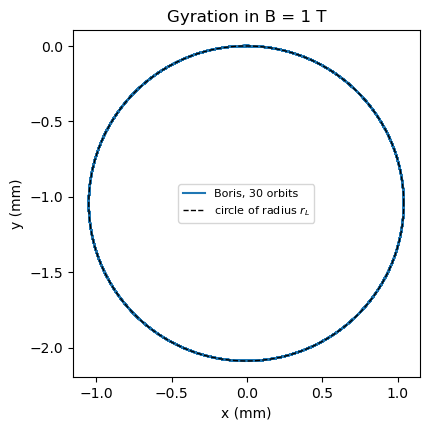

In [59]:
v0 = 1e5 #velocity
rL = M * v0 / (Q * B0)
d = run("gyration", [Q, M, 0, 0, 0, v0, 0, 0], steps=int(30 * Tc / dt)) #run boris psuher

center = (d["x"].min() + d["x"].max()) / 2, (d["y"].min() + d["y"].max()) / 2
radius = (d["x"].max() - d["x"].min()) / 2 # r_L
omega = -np.polyfit(d["t"], np.unwrap(np.arctan2(d["vy"], d["vx"])), 1)[0]   #takes the slope of fit, rotation rate of v

compare_value("gyration radius r_L", radius, rL, "m")
compare_value("gyration frequency omega_c", omega, wc, "rad/s")

circle = np.linspace(0, 2 * np.pi, 200)
plt.figure(figsize=(4.5, 4.5))
plt.plot(d["x"] * 1e3, d["y"] * 1e3, label="Boris, 30 orbits")
plt.plot((center[0] + rL * np.cos(circle)) * 1e3, (center[1] + rL * np.sin(circle)) * 1e3, "k--", lw=1, label="circle of radius $r_L$")
plt.gca().set(title="Gyration in B = 1 T", xlabel="x (mm)", ylabel="y (mm)", aspect="equal"); plt.legend(fontsize=8)
plt.savefig(FIG / "test1_gyration.png", dpi=110, bbox_inches="tight"); plt.show()

## Test 2 - Energy conservation

why --> no E so no work, only constant B so kinetic energy should remain the same


how --> Run 1000 orbits  in $B = 1$ T and check  $K = \tfrac12 m|\mathbf{v}|^2$  throughout.



kinetic energy after 1000 orbits                 code =  9.115789e-18 J      theory =  9.115789e-18 J
largest energy change over the run               code =  1.542497e-30 J      theory =  0.000000e+00 J


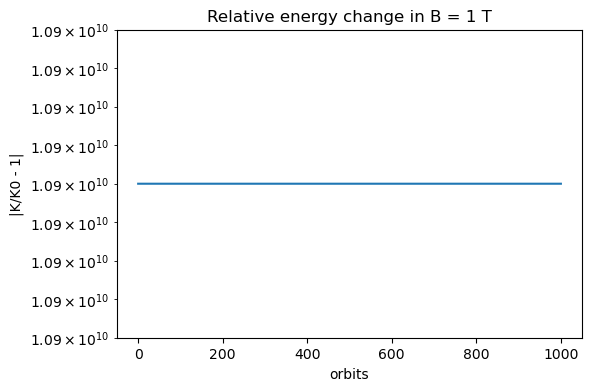

In [60]:
d = run("energy", [Q, M, 0, 0, 0, v0, 0, 3e4], steps=int(1000 * Tc / dt), stride=500)
K = d["vx"]**2 + d["vy"]**2 + d["vz"]**2
compare_value("kinetic energy after 1000 orbits", 0.5 * M * K[-1], 0.5 * M * K[0], "J")   # theory: unchanged
compare_value("largest energy change over the run", 0.5 * M * np.abs(K - K[0]).max(), 0.0, "J")

plt.figure(figsize=(6, 4))
plt.semilogy(np.arange(len(K)) * 500 * dt / Tc, K)
plt.gca().set(title="Relative energy change in B = 1 T", xlabel="orbits", ylabel="|K/K0 - 1|",ylim=(1.089999e10,1.090001e10))
plt.savefig(FIG / "test2_energy.png", dpi=110, bbox_inches="tight"); plt.show()

## Test 3 - E×B drift

why --> test action E

how --> In crossed fields $\mathbf{E} = (0, 10^4, 0)$ V/m and $\mathbf{B} = (0, 0, 1)$ T, charged particle drifts along $x$ at $v_d = E/B = 10^4$ m/s. One proton starting at rest + protons and alpha particles with random velocities.


The drift is measured from the guiding centre $x_{gc} = x + v_y/\omega_c$, 



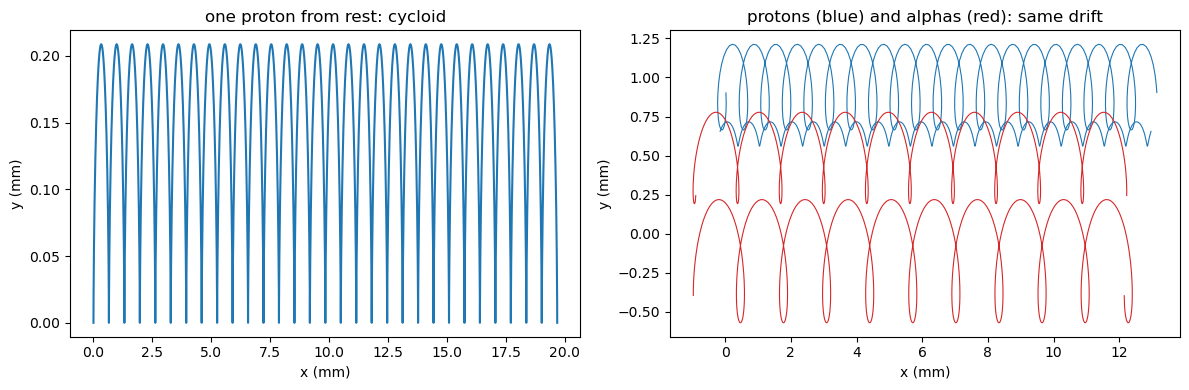

In [61]:
import pandas as pd

E0 = 1e4
theory = E0 / B0                                   # E x B drift, the same for every particle

def drift_speed(d, qm):
    # slope of the guiding-centre position x + v_y / omega
    return np.polyfit(d["t"], d["x"] + d["vy"] / (qm * B0), 1)[0]

one = run("drift_proton", [Q, M, 0, 0, 0, 0, 0, 0], E=(0, E0, 0), steps=int(30 * Tc / dt))
vd_one = drift_speed(one, Q / M)


rng = np.random.default_rng(1)
ens = [[Q, M] if k < 200 else [2 * Q, 4 * M] for k in range(400)]         # list of 400 (charge, mass) pairs
ens = [qm + [*rng.uniform(-1e-3, 1e-3, 2), 0, *rng.normal(0, 2e4, 3)] for qm in ens] # completes each particle into a full row read by boris_pusher
many = run("drift_mixed", ens, E=(0, E0, 0), steps=int(20 * Tc / dt), stride=25)
pid = many["pid"].astype(int)

# plots
fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(one["x"] * 1e3, one["y"] * 1e3)
ax[0].set(title="one proton from rest: cycloid", xlabel="x (mm)", ylabel="y (mm)")
for p, c in [(0, "C0"), (1, "C0"), (200, "C3"), (201, "C3")]:
    s = many[pid == p]; ax[1].plot(s["x"] * 1e3, s["y"] * 1e3, c, lw=0.8)
ax[1].set(title="protons (blue) and alphas (red): same drift", xlabel="x (mm)", ylabel="y (mm)")
fig.tight_layout(); fig.savefig(FIG / "test3_drift.png", dpi=110); plt.show()

In [62]:
rows = [("single proton", vd_one)]
for name, ids, qm in [("protons", range(200), Q / M), ("alphas", range(200, 400), Q / (2 * M))]:
    vd = np.mean([drift_speed(many[pid == p], qm) for p in ids])
    rows.append((f"200 {name}", vd))

# measured mean drift vs theory
table = pd.DataFrame(rows, columns=["group", "mean drift (m/s)"])
table["theory E/B (m/s)"] = theory
table["relative difference"] = (table["mean drift (m/s)"] / theory - 1).abs()
display(table.style.format({"mean drift (m/s)": "{:.2f}", "theory E/B (m/s)": "{:.2f}",
                            "relative difference": "{:.1e}"}))


,group,mean drift (m/s),theory E/B (m/s),relative difference
0,single proton,10000.00,10000.00,3.8e-09
1,200 protons,10000.00,10000.00,1.4e-07
2,200 alphas,9999.98,10000.00,1.7e-06


## Test 4 - N particles

why --> check it works with array


array push vs one-by-one push: bitwise identical
ring: smallest speed of the 64 particles         code =  1.000000e+05 m/s    theory =  1.000000e+05 m/s
ring: largest speed of the 64 particles          code =  1.000000e+05 m/s    theory =  1.000000e+05 m/s


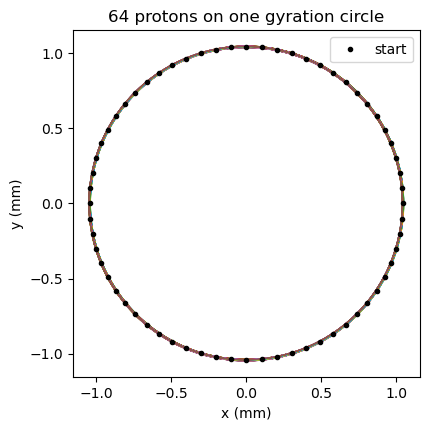

In [63]:
res = subprocess.run([BIN, "--selftest-array"], capture_output=True, text=True)


out = DATA / "ring.csv"
subprocess.run([BIN, "--run-ring", out, "n=64", "v0=1e5", "B=0,0,1", f"dt={dt}",
                f"steps={int(3 * Tc / dt)}", "stride=10"], check=True, capture_output=True)
r = np.genfromtxt(out, delimiter=",", names=True)
speed = np.sqrt(r["vx"]**2 + r["vy"]**2 + r["vz"]**2)
print("array push vs one-by-one push:", "bitwise identical" if res.returncode == 0 else "DIFFERENT")
compare_value("ring: smallest speed of the 64 particles", speed.min(), 1e5, "m/s")
compare_value("ring: largest speed of the 64 particles", speed.max(), 1e5, "m/s")

plt.figure(figsize=(4.5, 4.5))
for p in range(0, 64, 4):
    s = r["pid"] == p; plt.plot(r["x"][s] * 1e3, r["y"][s] * 1e3, lw=0.8)
s = r["t"] == 0; plt.plot(r["x"][s] * 1e3, r["y"][s] * 1e3, "k.", label="start")
plt.gca().set(title="64 protons on one gyration circle", xlabel="x (mm)", ylabel="y (mm)", aspect="equal")
plt.legend(); plt.savefig(FIG / "test4_ring.png", dpi=110, bbox_inches="tight"); plt.show()

## Test 5 - Mixed species in one array

why --> more tests on array and different charge/mass, should be fine

How -->  50 of each particle (proton, alpha, oxygen ion), test drift and gyration 

protons: gyration frequency qB/m                 code =  9.577662e+07 rad/s  theory =  9.578833e+07 rad/s
protons: drift speed E/B                         code =  1.000000e+04 m/s    theory =  1.000000e+04 m/s
alphas: gyration frequency qB/m                  code =  4.789270e+07 rad/s  theory =  4.789417e+07 rad/s
alphas: drift speed E/B                          code =  1.000000e+04 m/s    theory =  1.000000e+04 m/s
O+: gyration frequency qB/m                      code =  5.986768e+06 rad/s  theory =  5.986771e+06 rad/s
O+: drift speed E/B                              code =  1.000000e+04 m/s    theory =  1.000000e+04 m/s


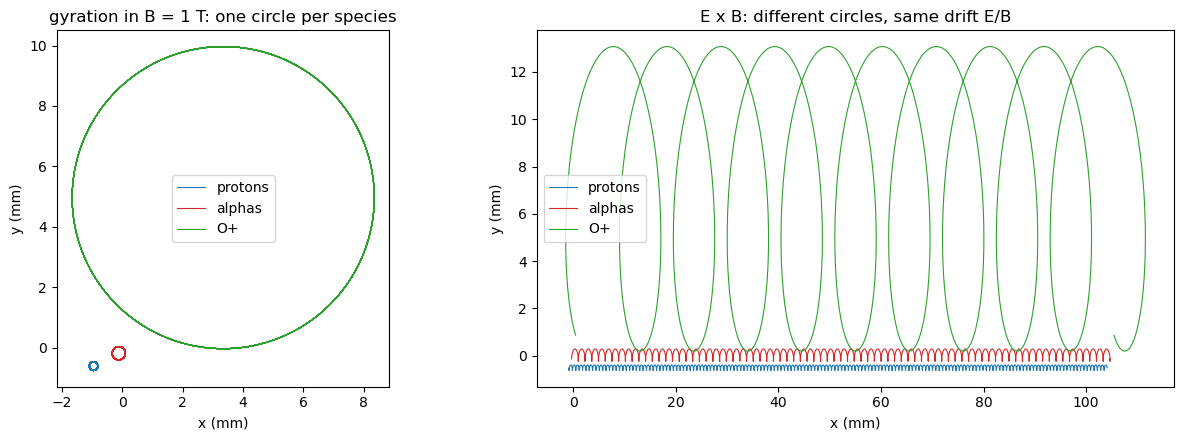

In [64]:
species = [("protons", Q, M), ("alphas", 2 * Q, 4 * M), ("O+", Q, 16 * M)]
rng = np.random.default_rng(3)
ions = [[q, m, *rng.uniform(-1e-3, 1e-3, 2), 0, *rng.normal(0, 2e4, 3)] for _, q, m in species for _ in range(50)]

dt6 = 4e-10                                   # larger step: 10 slow O+ orbits in a reasonable run
ic = DATA / "species_ic.csv"
np.savetxt(ic, ions, delimiter=",", header="q,m,x,y,z,vx,vy,vz", comments="")

def run_species(name, E):
    # push the mixed array with the larger time step; return the trajectory table
    out = DATA / f"{name}.csv"
    subprocess.run([BIN, "--run-array", out, ic, f"E=0,{E},0", "B=0,0,1", f"dt={dt6}",
                    f"steps={int(10 * 16 * Tc / dt6)}", "stride=20"], check=True, capture_output=True)
    return np.genfromtxt(out, delimiter=",", names=True)

gyr = run_species("species_gyration", 0)      # B only
dri = run_species("species_drift", E0)        # E x B
t = np.unique(gyr["t"])
vx, vy = (gyr[c].reshape(len(t), len(ions)) for c in ("vx", "vy"))

# gyration: frequency of each particle = rate at which its velocity turns
omega = -np.polyfit(t, np.unwrap(np.arctan2(vy, vx), axis=0), 1)[0]
pid = dri["pid"].astype(int)
for k, (name, q, m) in enumerate(species):
    compare_value(f"{name}: gyration frequency qB/m", omega[50 * k: 50 * (k + 1)].mean(), q * B0 / m, "rad/s")
    vd = np.mean([drift_speed(dri[pid == p], q / m) for p in range(50 * k, 50 * (k + 1))])
    compare_value(f"{name}: drift speed E/B", vd, E0 / B0, "m/s")

# plots: one particle of each species, gyration (B only) and drift (E x B)
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
gpid = gyr["pid"].astype(int)
for k, ((name, q, m), col) in enumerate(zip(species, ["C0", "C3", "C2"])):
    p = 50 * k
    s = gyr[gpid == p]; ax[0].plot(s["x"] * 1e3, s["y"] * 1e3, col, lw=0.8, label=name)
    s = dri[pid == p];  ax[1].plot(s["x"] * 1e3, s["y"] * 1e3, col, lw=0.8, label=name)
ax[0].set(title="gyration in B = 1 T: one circle per species", xlabel="x (mm)", ylabel="y (mm)", aspect="equal")
ax[1].set(title="E x B: different circles, same drift E/B", xlabel="x (mm)", ylabel="y (mm)")
ax[0].legend(); ax[1].legend()
fig.tight_layout(); fig.savefig(FIG / "test5_species.png", dpi=110); plt.show()